In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary

import matplotlib.pyplot as plt
import numpy as np
import os
import random

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix
from dataclasses import dataclass, field
import seaborn as sns
import json

In [63]:
SEED = 42

random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: mps


In [65]:
class Transforms:
    def __init__(self, tranforms):
        self.transforms = tranforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

In [66]:
def back_to_image(img):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    npimg = np.clip(img.numpy() * std + mean, 0, 1)
    return np.transpose(npimg, (1, 2, 0))

In [67]:
def show_data_examples(trainset, iteration, classes):
    num_row = 2
    num_col = 5
    fig, axes = plt.subplots(num_row, num_col, figsize=(10*num_row, 2*num_col))
    for i in range(num_row*num_col):
        ax = axes[i//num_col, i%num_col]
        ax.imshow(back_to_image(trainset[iteration * num_row * num_col + i][0]))
        ax.set_title('{}'.format(classes[int(trainset[iteration*num_row*num_col+i][1])]))
    plt.tight_layout()
    plt.show()

## Training Utilities

In [68]:
@dataclass
class Experiment:
  "This class represents an experiment: a model and all its hyperparameters"
  name: str
  checkpoints_folder: str
  checkpoint_name: str
  model: object
  use_early_stopping: bool
  criterion: object
  color: str
  alpha: float
  optimizer: object
  logs: str = None
  checkpoint_save_path: str = None
  val_loss: float = None
  train_loader: object = None
  val_loader: object = None
  lr: float = 1e-5
  epochs: int = 50
  patience: int = 5
  min_delta: float = 0
  scheduler_fn: object = None
  epoch_count: list = field(default_factory=list)
  val_loss_values: list = field(default_factory=list)
  train_loss_values: list = field(default_factory=list)
  test_accuracy_values: list = field(default_factory=list)
  plt_args_training: dict = field(default_factory=dict)
  plt_args_validation: dict = field(default_factory=dict)

  def __post_init__(self):
    self.model = self.model()
    self.optimizer = self.optimizer(
      params=self.model.parameters(),
      lr=self.lr
    )
    self.scheduler = self.scheduler_fn(self.optimizer) if self.scheduler_fn else None
    self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name)
    os.makedirs(self.checkpoints_folder, exist_ok=True)
    self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)
    self.logs = os.path.join(self.checkpoints_folder, 'logs.json')

In [69]:
def _save_experiment(exp: Experiment):
    os.makedirs(os.path.dirname(exp.checkpoint_save_path), exist_ok=True)
    torch.save(exp.model.state_dict(), exp.checkpoint_save_path)
    logs = {
        "train_losses": exp.train_loss_values,
        "val_losses": exp.val_loss_values,
        "val_accuracies": exp.test_accuracy_values,
    }
    with open(exp.logs, 'w') as f:
        json.dump(logs, f)


def _load_experiment(exp: Experiment, device):
    """Return True if a completed run was found on disk and loaded."""
    if not (os.path.exists(exp.logs) and os.path.exists(exp.checkpoint_save_path)):
        return False
    with open(exp.logs, 'r') as f:
        logs = json.load(f)
    exp.train_loss_values = logs['train_losses']
    exp.val_loss_values = logs['val_losses']
    exp.test_accuracy_values = logs['val_accuracies']
    exp.epoch_count = list(range(len(exp.train_loss_values)))
    exp.model.load_state_dict(torch.load(exp.checkpoint_save_path, map_location=device))
    exp.model.to(device)
    print(f"[{exp.name}] Loaded from disk ({len(exp.epoch_count)} epochs already trained). Skipping training.")
    return True


In [70]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False
    
    def __call__(self, validation_loss, exp: Experiment):
        if self.min_val_loss is None:                                   # First epoch
            self.min_val_loss = validation_loss
            _save_experiment(exp)

        elif (self.min_val_loss - validation_loss) > self.min_delta:   # Model is getting better
            self.min_val_loss = validation_loss
            _save_experiment(exp)
            self.counter = 0

        else:                                                           # Model is NOT getting better
            self.counter += 1
            if self.counter >= self.patience:                           # Patience reached -> stop training
                self.early_stop = True

In [71]:
def train_epoch(exp: Experiment, device):
    exp.model.train()
    running_loss = 0
    processed_data = 0

    for i, data in enumerate(exp.train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        exp.optimizer.zero_grad()

        outputs = exp.model(inputs)
        loss = exp.criterion(outputs, labels)
        loss.backward()
        exp.optimizer.step()

        running_loss += loss.item()
        processed_data += len(inputs)
    
    return running_loss / processed_data

In [72]:
def test_epoch(exp: Experiment, device):
    exp.model.eval()
    running_loss = 0
    process_data = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(exp.val_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = exp.model(inputs)
            loss = exp.criterion(outputs, labels)

            running_loss += loss.item()
            process_data += len(inputs)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return running_loss / process_data, correct / total

In [73]:
def train(exp: Experiment, device):
    if _load_experiment(exp, device):
        return

    exp.model.to(device)

    if exp.use_early_stopping:
        early_stopping = EarlyStopping(exp.checkpoint_save_path, patience=exp.patience, min_delta=exp.min_delta)

    for epoch in range(exp.epochs):
        train_loss = train_epoch(exp, device)
        val_loss, val_accuracy = test_epoch(exp, device)

        if exp.scheduler:
            exp.scheduler.step(val_loss)

        exp.epoch_count.append(epoch)
        exp.train_loss_values.append(train_loss)
        exp.val_loss_values.append(val_loss)
        exp.test_accuracy_values.append(val_accuracy)

        print(f"Epoch {epoch:<3}  |  Train loss: {train_loss:.6f}  |  Val loss: {val_loss:.6f}  |  Val accuracy: {val_accuracy*100:.2f}%")

        if exp.use_early_stopping:
            early_stopping(val_loss, exp)
            if early_stopping.early_stop:
                print(f"Early stopping at epoch {epoch}")
                break
    
    if not exp.use_early_stopping:
        _save_experiment(exp)

In [74]:
def plot_confusion_matrix(model, test_loader, device, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')

In [75]:
transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

In [76]:
valset = torchvision.datasets.ImageFolder(root='dataset/val', transform=Transforms(transform))

testset = torchvision.datasets.ImageFolder(root='dataset/test', transform=Transforms(transform))

In [77]:
augment = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),

        A.RandomRotate90(),
        A.OneOf(
            [
                A.HorizontalFlip(),
                A.VerticalFlip(),
            ], p= 0.6
        ),
        A.Transpose(),
        A.OneOf(
            [
                A.Affine(shear=20),
                A.Affine(scale=1.2)
            ], p=0.6
        ),

        ToTensorV2(),
    ]
)

In [78]:
trainset = torchvision.datasets.ImageFolder(root='dataset/train', transform=Transforms(augment))

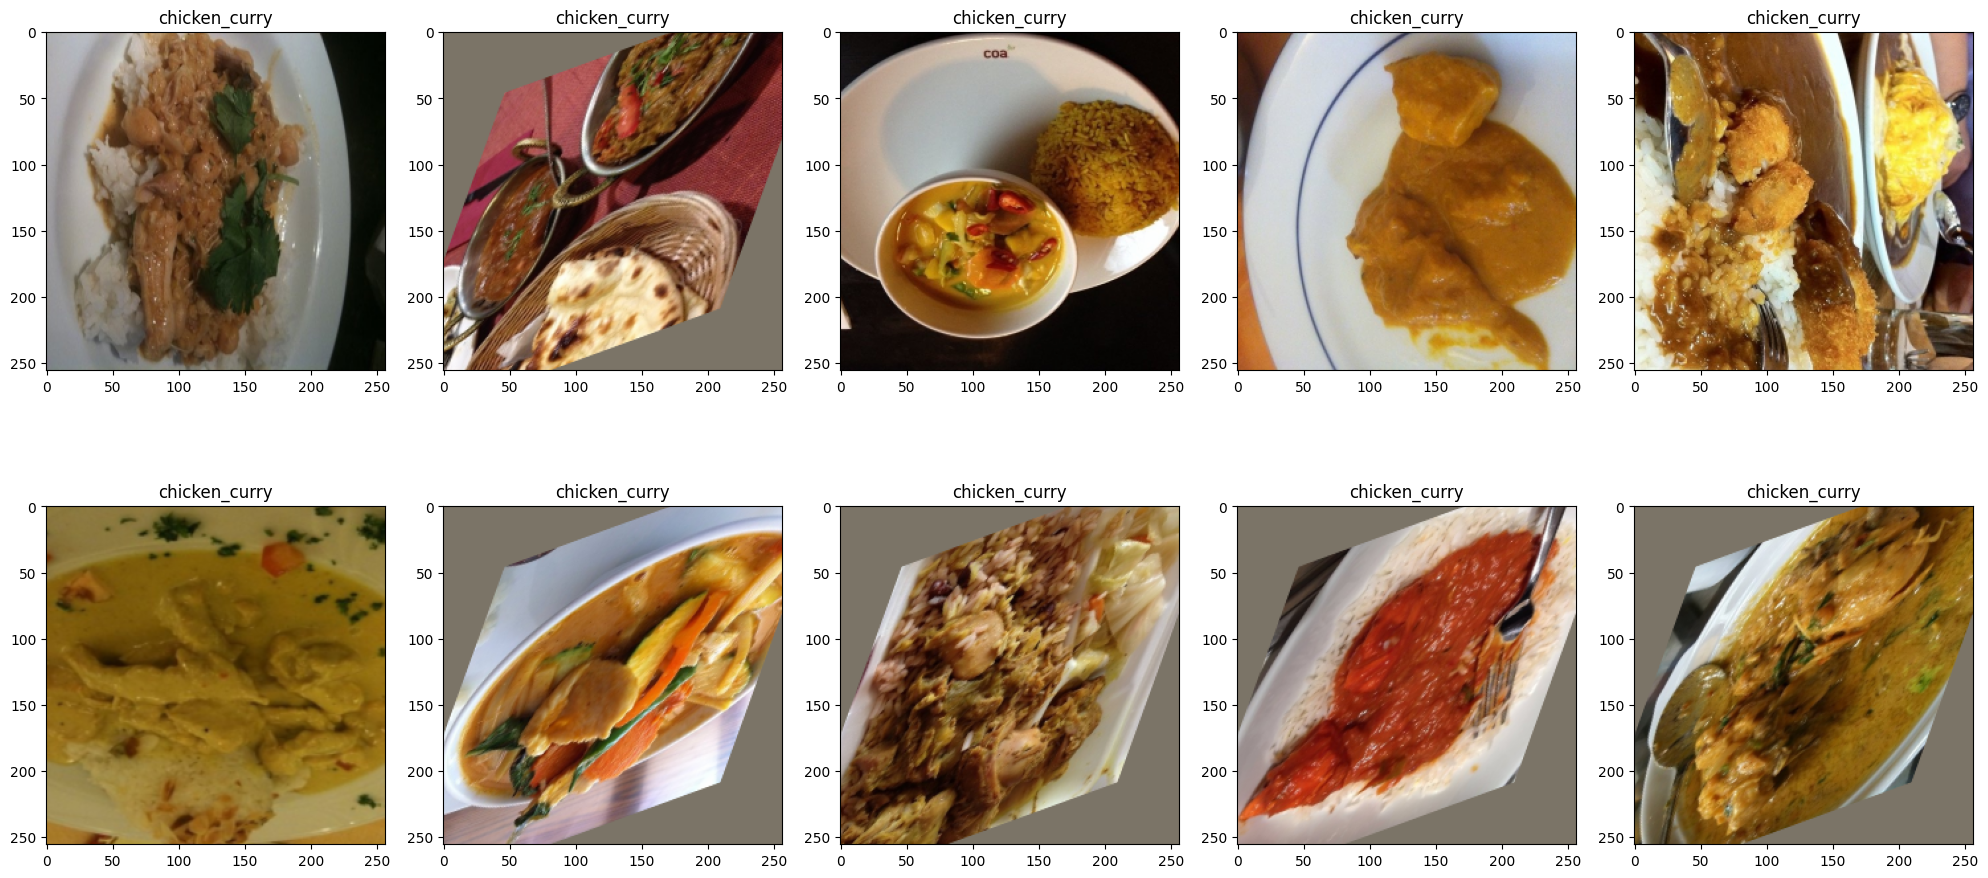

In [79]:
show_data_examples(trainset, random.randint(0, 895), trainset.classes)

## Data Loaders

In [80]:
BATCH_SIZE = 32

pin_memory = device.type == device

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

num_classes = len(trainset.classes)
print(f"Classes ({num_classes}):\n{trainset.classes}")

Classes (14):
['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'cheesecake', 'chicken_curry', 'ice_cream', 'omelette', 'sushi']


## Model Factories

Each factory freezes the pretrained backbone and replaces only the final classification head.
The returned callable is what `Experiment.__post_init__` calls to instantiate the model.

In [81]:
def make_head(in_features, num_classes, dropout=0.3):
    return nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes),
    )


def make_resnet50(num_classes):
    def factory():
        model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = make_head(model.fc.in_features, num_classes)
        return model
    return factory


def make_efficientnet_b0(num_classes):
    def factory():
        model = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        # classifier is Sequential([Dropout, Linear]) — replace the Linear
        model.classifier[1] = make_head(model.classifier[1].in_features, num_classes)
        return model
    return factory


def make_mobilenet_v3_small(num_classes):
    def factory():
        model = torchvision.models.mobilenet_v3_small(weights=torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        # classifier is Sequential([Linear, Hardswish, Dropout, Linear]) — replace the last Linear
        model.classifier[3] = make_head(model.classifier[3].in_features, num_classes)
        return model
    return factory

## Experiments

In [82]:
CHECKPOINTS_FOLDER = 'checkpoints'

_scheduler_fn = lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

experiments = [
    Experiment(
        name='resnet50',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_resnet50(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='steelblue',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=30,
        patience=5,
        scheduler_fn=_scheduler_fn,
    ),
    Experiment(
        name='efficientnet_b0',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_efficientnet_b0(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='darkorange',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=30,
        patience=5,
        scheduler_fn=_scheduler_fn,
    ),
    Experiment(
        name='mobilenet_v3_small',
        checkpoints_folder=CHECKPOINTS_FOLDER,
        checkpoint_name='best.pt',
        model=make_mobilenet_v3_small(num_classes),
        use_early_stopping=True,
        criterion=nn.CrossEntropyLoss(),
        color='seagreen',
        alpha=0.9,
        optimizer=torch.optim.Adam,
        train_loader=trainloader,
        val_loader=valloader,
        lr=1e-3,
        epochs=30,
        patience=5,
        scheduler_fn=_scheduler_fn,
    ),
]

## Smoke Test

Runs every model for 2 epochs on a single batch to verify the full pipeline
(forward pass, backward pass, early stopping, disk save, disk reload) without waiting for real training.

In [83]:
import shutil
from torch.utils.data import Subset

SMOKE_CHECKPOINTS = 'checkpoints_smoke'

def run_smoke_test(factories, num_classes, device):
    # One batch worth of samples for each split
    mini_train = Subset(trainset, range(BATCH_SIZE))
    mini_val   = Subset(valset,   range(BATCH_SIZE))
    mini_trainloader = torch.utils.data.DataLoader(mini_train, batch_size=BATCH_SIZE, shuffle=False)
    mini_valloader   = torch.utils.data.DataLoader(mini_val,   batch_size=BATCH_SIZE, shuffle=False)

    smoke_experiments = [
        Experiment(
            name=name,
            checkpoints_folder=SMOKE_CHECKPOINTS,
            checkpoint_name='best.pt',
            model=factory(num_classes),
            use_early_stopping=True,
            criterion=nn.CrossEntropyLoss(),
            color='gray',
            alpha=1.0,
            optimizer=torch.optim.Adam,
            train_loader=mini_trainloader,
            val_loader=mini_valloader,
            lr=1e-3,
            epochs=2,
            patience=1,
        )
        for name, factory in factories.items()
    ]

    print("=== Smoke Test: Training Pass ===")
    for exp in smoke_experiments:
        train(exp, device)

        # --- basic sanity checks ---
        assert len(exp.train_loss_values) == 2,       f"{exp.name}: expected 2 train losses, got {len(exp.train_loss_values)}"
        assert len(exp.val_loss_values) == 2,         f"{exp.name}: expected 2 val losses"
        assert len(exp.test_accuracy_values) == 2,    f"{exp.name}: expected 2 accuracy values"
        assert exp.epoch_count == [0, 1],             f"{exp.name}: epoch_count wrong: {exp.epoch_count}"
        assert not any(v != v for v in exp.train_loss_values), f"{exp.name}: NaN in train losses"
        assert os.path.exists(exp.checkpoint_save_path),       f"{exp.name}: checkpoint not saved"
        assert os.path.exists(exp.logs),                       f"{exp.name}: logs.json not saved"

        print(f"  {exp.name}: train loss={exp.train_loss_values[-1]:.4f}  val acc={exp.test_accuracy_values[-1]*100:.1f}%  ✓")

    print("\n=== Smoke Test: Reload-from-Disk Pass ===")
    for exp in smoke_experiments:
        metrics_before = (exp.train_loss_values.copy(), exp.val_loss_values.copy())

        # Re-create the experiment — __post_init__ resets all lists
        reloaded = Experiment(
            name=exp.name,
            checkpoints_folder=SMOKE_CHECKPOINTS,
            checkpoint_name='best.pt',
            model={n: f for n, f in factories.items()}[exp.name](num_classes),
            use_early_stopping=True,
            criterion=nn.CrossEntropyLoss(),
            color='gray',
            alpha=1.0,
            optimizer=torch.optim.Adam,
            train_loader=exp.train_loader,
            val_loader=exp.val_loader,
            lr=1e-3,
            epochs=2,
            patience=1,
        )
        train(reloaded, device)  # should load from disk, not retrain

        assert reloaded.train_loss_values == metrics_before[0], f"{exp.name}: reloaded metrics don't match"
        print(f"  {exp.name}: reload from disk ✓")

    print("\nAll smoke tests passed.")
    shutil.rmtree(SMOKE_CHECKPOINTS)
    print(f"Cleaned up '{SMOKE_CHECKPOINTS}/'")


factories = {
    'resnet50':          make_resnet50,
    'efficientnet_b0':   make_efficientnet_b0,
    'mobilenet_v3_small': make_mobilenet_v3_small,
}

run_smoke_test(factories, num_classes, device)

=== Smoke Test: Training Pass ===
Epoch 0    |  Train loss: 0.083558  |  Val loss: 0.039896  |  Val accuracy: 100.00%
Epoch 1    |  Train loss: 0.042760  |  Val loss: 0.017532  |  Val accuracy: 100.00%
  resnet50: train loss=0.0428  val acc=100.0%  ✓
Epoch 0    |  Train loss: 0.088751  |  Val loss: 0.060864  |  Val accuracy: 100.00%
Epoch 1    |  Train loss: 0.066308  |  Val loss: 0.049749  |  Val accuracy: 100.00%
  efficientnet_b0: train loss=0.0663  val acc=100.0%  ✓
Epoch 0    |  Train loss: 0.084828  |  Val loss: 0.064895  |  Val accuracy: 75.00%
Epoch 1    |  Train loss: 0.062696  |  Val loss: 0.049964  |  Val accuracy: 100.00%
  mobilenet_v3_small: train loss=0.0627  val acc=100.0%  ✓

=== Smoke Test: Reload-from-Disk Pass ===
[resnet50] Loaded from disk (2 epochs already trained). Skipping training.
  resnet50: reload from disk ✓
[efficientnet_b0] Loaded from disk (2 epochs already trained). Skipping training.
  efficientnet_b0: reload from disk ✓
[mobilenet_v3_small] Loaded fr

In [84]:
do_train = True

In [85]:
if do_train:
    for exp in experiments:
        print(f"\n{'='*60}")
        print(f"  {exp.name}")
        print(f"{'='*60}")
        train(exp, device)


  resnet50
Epoch 0    |  Train loss: 0.038093  |  Val loss: 0.022722  |  Val accuracy: 76.25%
Epoch 1    |  Train loss: 0.028866  |  Val loss: 0.020965  |  Val accuracy: 78.57%
Epoch 2    |  Train loss: 0.027253  |  Val loss: 0.020564  |  Val accuracy: 78.44%
Epoch 3    |  Train loss: 0.026799  |  Val loss: 0.020634  |  Val accuracy: 78.79%
Epoch 4    |  Train loss: 0.026930  |  Val loss: 0.020141  |  Val accuracy: 78.93%
Epoch 5    |  Train loss: 0.026081  |  Val loss: 0.020006  |  Val accuracy: 80.09%
Epoch 6    |  Train loss: 0.026429  |  Val loss: 0.020360  |  Val accuracy: 79.51%
Epoch 7    |  Train loss: 0.025631  |  Val loss: 0.020266  |  Val accuracy: 80.27%
Epoch 8    |  Train loss: 0.025859  |  Val loss: 0.020683  |  Val accuracy: 79.42%
Epoch 9    |  Train loss: 0.026141  |  Val loss: 0.019428  |  Val accuracy: 80.71%
Epoch 10   |  Train loss: 0.024669  |  Val loss: 0.020446  |  Val accuracy: 79.60%
Epoch 11   |  Train loss: 0.025132  |  Val loss: 0.019688  |  Val accuracy:

## Results Comparison

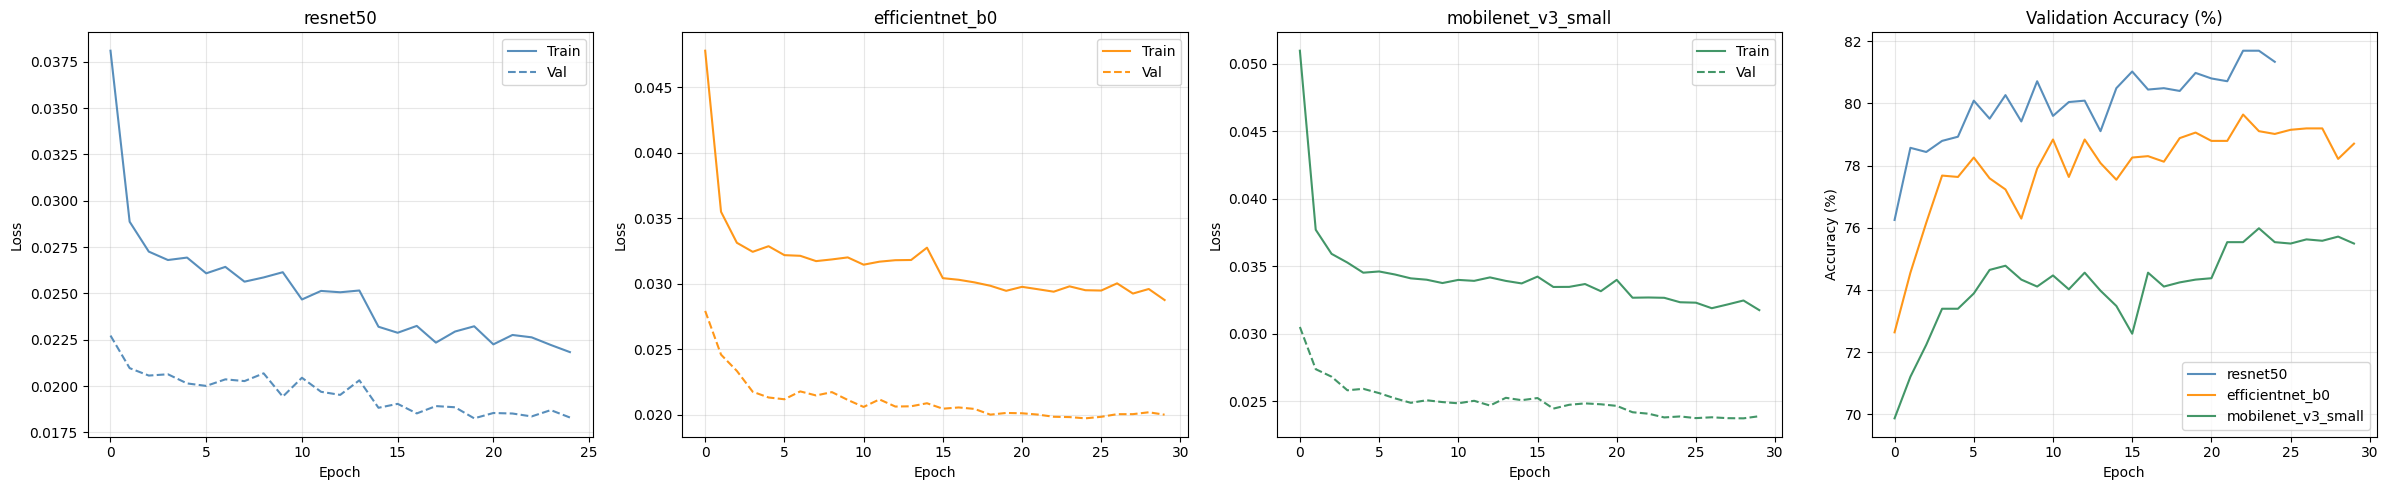

In [96]:
def plot_experiment_comparison(experiments):
    ncols = len(experiments) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

    for ax, exp in zip(axes, experiments):
        ax.plot(exp.epoch_count, exp.train_loss_values,
                label='Train', color=exp.color, alpha=exp.alpha)
        ax.plot(exp.epoch_count, exp.val_loss_values,
                label='Val', color=exp.color, alpha=exp.alpha, linestyle='--')
        ax.set_title(exp.name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)

    acc_ax = axes[-1]
    for exp in experiments:
        acc_ax.plot(exp.epoch_count, [a * 100 for a in exp.test_accuracy_values],
                    label=exp.name, color=exp.color, alpha=exp.alpha)
    acc_ax.set_title('Validation Accuracy (%)')
    acc_ax.set_xlabel('Epoch')
    acc_ax.set_ylabel('Accuracy (%)')
    acc_ax.legend()
    acc_ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_experiment_comparison(experiments)

In [87]:
def print_experiment_summary(experiments):
    print(f"{'Model':<25} {'Best Val Loss':>14} {'Best Val Acc':>13} {'Epochs Run':>11}")
    print('-' * 67)
    for exp in experiments:
        best_loss = min(exp.val_loss_values) if exp.val_loss_values else float('nan')
        best_acc  = max(exp.test_accuracy_values) * 100 if exp.test_accuracy_values else float('nan')
        epochs    = len(exp.epoch_count)
        print(f"{exp.name:<25} {best_loss:>14.6f} {best_acc:>12.2f}% {epochs:>11}")

print_experiment_summary(experiments)

Model                      Best Val Loss  Best Val Acc  Epochs Run
-------------------------------------------------------------------
resnet50                        0.018256        81.70%          25
efficientnet_b0                 0.019738        79.64%          30
mobilenet_v3_small              0.023746        75.98%          30


Confusion matrix for: resnet50


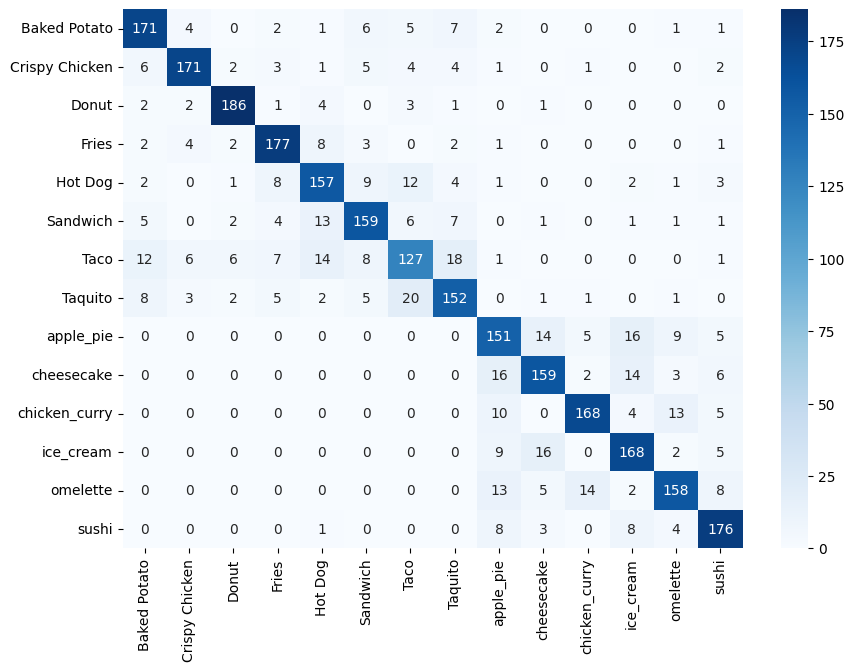

In [88]:
# Confusion matrix for the best-performing experiment
best_exp = max(experiments, key=lambda e: max(e.test_accuracy_values) if e.test_accuracy_values else 0)
print(f"Confusion matrix for: {best_exp.name}")
plot_confusion_matrix(best_exp.model, testloader, device, testset.classes)

In [ ]:
loss, accuracy = test_epoch(best_exp, device)
print(f"Best Exp: {best_exp.name}\nTest Loss: {loss}   |   Test Accuracy: {accuracy*100:.2f}")

Best Exp: resnet50
Test Loss: 0.018301149337951628   |   Test Accuracy: 81.34
